In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
from variables import *
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

matr = read_complex_matrix('ref_matrix.txt')
import timeit

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


In [2]:
data = np.loadtxt('experiment.txt')

r = data[:, 1]
r2 = data[:, 1] + data[:, 2]
r1 = data[:, 1] - data[:, 2]
sigma = sigma+0.0
Ibkg=Ibkg+0.0
I0_plus = np.mean(r[r > 0.9*r1[0]][0:1+math.ceil(len(r[r > 0.9*r1[0]])*0.7)])
I0 = torch.tensor(I0_plus).requires_grad_(True) - Ibkg

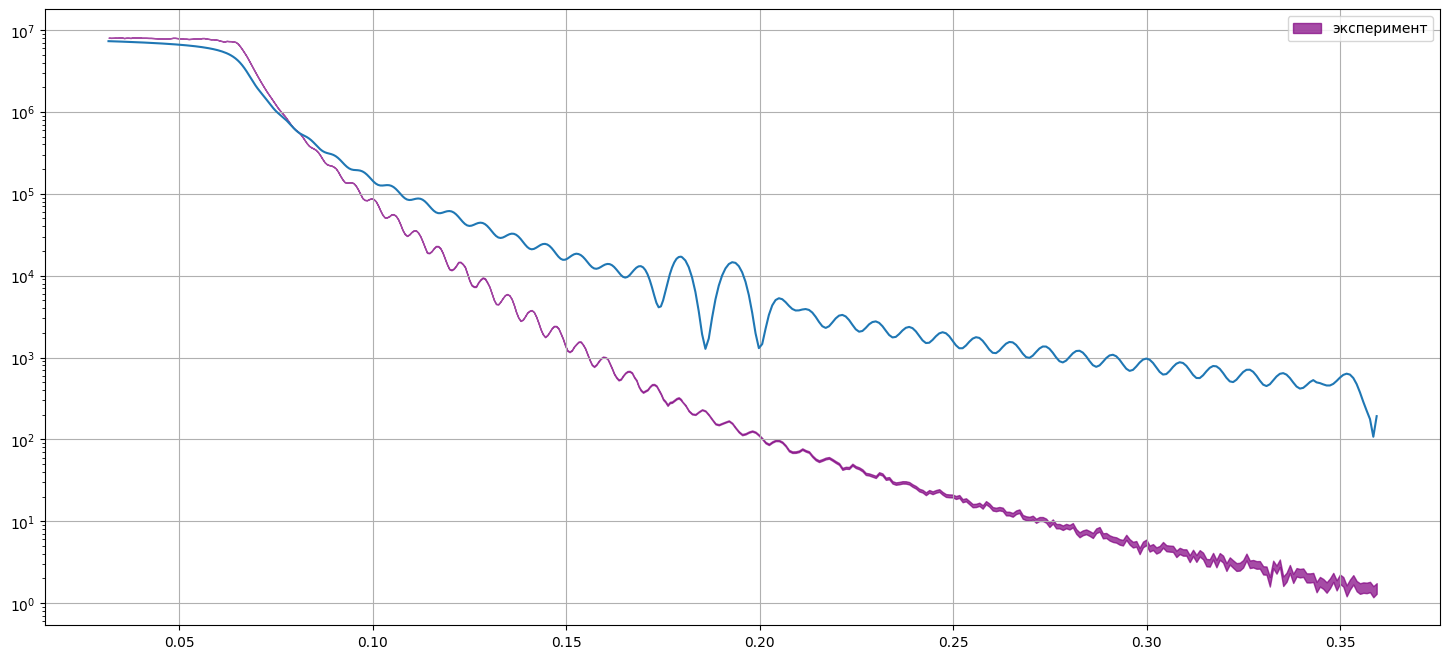

In [3]:
q = torch.pi*4.0e+10*torch.sin(torch.tensor(np.deg2rad(data[:, 0])))/1.524
r_mod, r_mod_conv= reflectometry(q, matr, sigma, sigma, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.fill_between(q*1e-10, r1, r2, color='purple', alpha=0.7, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10, (I0*r_mod_conv).tolist())
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

In [4]:
r = torch.tensor(data[:, 1], requires_grad = True)/I0

In [5]:
from objective_function import *

loss_function = Comparator(q, matr, 10*sigma, 6*sigma, I0, Ibkg)

objective_function = varbounds(all_bounds, loss_function.compare)
objective_function_weightless = varbounds(all_bounds, loss_function.compare_weightless)

In [6]:
initial_d = torch.tensor([700.0,  50.0, 20.0,  10.0, 100, 0], requires_grad=True)
initial_r_rho = torch.tensor([88.575,  7.5, 8.575], requires_grad=True)
initial_i_rho = torch.tensor([-7.648, 0, -10.111], requires_grad=True)

initial_sigma = torch.tensor(0.01, requires_grad=True)

I_bounds =  torch.tensor([0.997*I0 , 1.003*I0]).requires_grad_(True)
Ibkg_bounds = torch.tensor([0.0, 3*Ibkg]).requires_grad_(True)

r_rho_bounds = torch.tensor([[80.0, 97.0], [-10.0, 20.0], [4.0, 14.0]], requires_grad=True)
i_rho_bounds = torch.tensor([[-70.0, -7.0], [-20.0, 0.0], [-20.0, -0.1]], requires_grad=True)

initial_sigma1 = torch.nn.Parameter(torch.tensor(0.01, dtype=torch.float64))
initial_sigma2 = torch.nn.Parameter(torch.tensor(0.01, dtype=torch.float64))
sigma_bounds1 =  torch.tensor([0.001 , 0.02]).requires_grad_(False)
sigma_bounds2 =  torch.tensor([0.001 , 0.02]).requires_grad_(False)

In [7]:
d_bounds

tensor([[5.0000e+02, 9.0000e+02],
        [1.0000e+00, 5.5000e+02],
        [0.0000e+00, 1.0000e+02],
        [0.0000e+00, 1.0000e+01],
        [9.9990e+01, 1.0000e+02],
        [0.0000e+00, 1.0000e-03]], grad_fn=<IndexBackward0>)

In [8]:
objective_function_weightless.objective_function(initial_d, torch.complex(initial_r_rho, initial_i_rho), sigma1, sigma2, I0, Ibkg)

tensor(9.3653, dtype=torch.float64, grad_fn=<SumBackward0>)

In [9]:
objective_function.objective_function(initial_d, torch.complex(initial_r_rho, initial_i_rho), sigma1, sigma2, I0, Ibkg)

tensor(0.0030, dtype=torch.float64, grad_fn=<SumBackward0>)

relative_loss:   1.0 
 d:   tensor([7.0499e+02, 5.4993e+01, 1.5000e+01, 1.0000e+01, 1.0000e+02, 1.0000e-03])     grad_d:   tensor([-4.3402e-06, -7.3725e-06,  3.0224e-04, -1.2487e-04,  0.0000e+00,
        -2.1297e-03]) 
 rho:   tensor([88.5700-8.0980j,  7.4950-0.4500j,  8.5700-10.5606j])     grad_rho:   tensor([4.0048e-04+1.4970e-02j, 5.4149e-04+5.9638e-03j, 1.7423e-05+1.1559e-05j]) 
 I:   tensor(7972341.5137, dtype=torch.float64)     grad_I:   tensor(-7.1942e-16, dtype=torch.float64) 
 Ibkg:   tensor(1.0657, dtype=torch.float64)     grad_Ibkg:   tensor(5.2117e-09, dtype=torch.float64) 
 learning_rate:   5.0 
 iteration:   1 



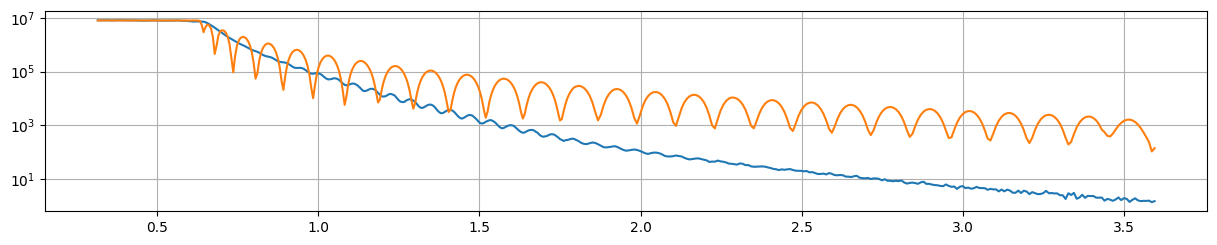

relative_loss:   0.5534507303275643 
 d:   tensor([807.5097, 156.2418,  14.0670,   0.0000, 100.0000,   0.0000])     grad_d:   tensor([-4.2781e-07,  6.6673e-08, -3.7950e-07, -2.2676e-08,  0.0000e+00,
         1.3625e-03]) 
 rho:   tensor([88.7746-7.9992j,  7.6601+0.0000j,  8.5192-7.0844j])     grad_rho:   tensor([-2.3748e-03+1.6405e-05j, -1.4667e-04-4.0573e-03j,
         8.2175e-07+2.8114e-07j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(1.9287e-14, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-4.6434e-08, dtype=torch.float64) 
 learning_rate:   4.70596 
 iteration:   60 



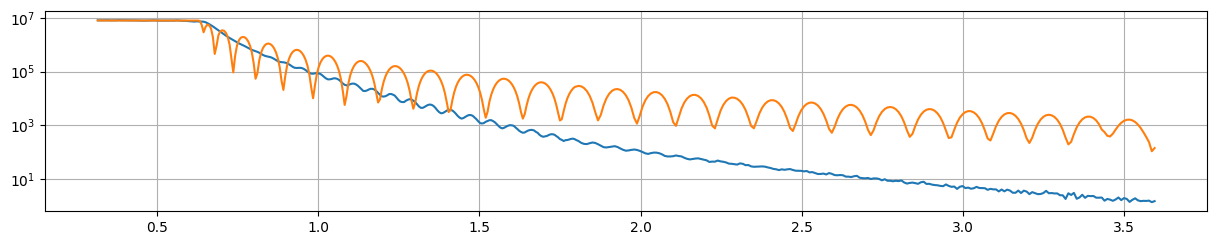

relative_loss:   0.5789967652814476 
 d:   tensor([852.4061, 154.8102,  17.2949,   0.0000, 100.0000,   0.0000])     grad_d:   tensor([-2.2059e-08, -1.1971e-08, -1.5755e-04,  9.1825e-05,  0.0000e+00,
         3.3283e-03]) 
 rho:   tensor([88.9892-7.9879j,  7.9017+0.0000j,  8.4634-7.6276j])     grad_rho:   tensor([-4.4283e-03-8.4869e-03j, -5.4189e-04-1.0242e-02j,
         6.6845e-07-5.6697e-08j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(3.8297e-14, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-9.2201e-08, dtype=torch.float64) 
 learning_rate:   4.519603984000001 
 iteration:   119 



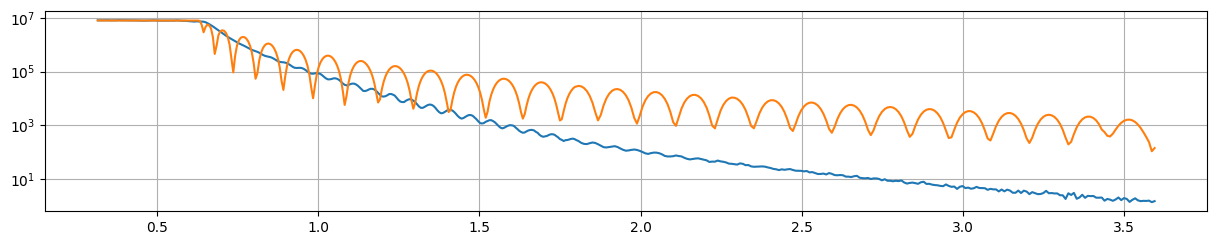

In [10]:
from optimizer import *
ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss, rel_losses1 = adamw(q, r, objective_function.objective_function, initial_sigma1, initial_sigma2,
                                                                      initial_d, initial_r_rho, initial_i_rho, I0, Ibkg, 
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.005, max_iter = 120, k=3)


In [11]:
objective_function_sigma = varsigma(ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss_function.compare, all_bounds)

from scipy.optimize import differential_evolution as de

bounds = [sigma_bounds1,
          sigma_bounds2]

ans_sigma1, ans_sigma2 = de(
    func=objective_function_sigma.objective_function,
    bounds=bounds
).x

relative_loss:   1.0 
 d:   tensor([844.6365, 146.8656,   8.1081,   8.1593, 100.0000,   0.0000])     grad_d:   tensor([ 2.4676e-02,  5.9605e-04,  6.4464e+00, -3.1334e+00,  0.0000e+00,
         5.8818e+00]) 
 rho:   tensor([88.9845-8.7745j,  7.9112+0.0000j,  8.4542-6.9013j])     grad_rho:   tensor([ 3.3870+0.0816j, -2.8940-2.2366j,  0.1250-0.1059j]) 
 I:   tensor(7992650.6583, dtype=torch.float64)     grad_I:   tensor(-5.7392e-08, dtype=torch.float64) 
 Ibkg:   tensor(3.1400, dtype=torch.float64)     grad_Ibkg:   tensor(0.1382, dtype=torch.float64) 
 learning_rate:   8.0 
 iteration:   1 



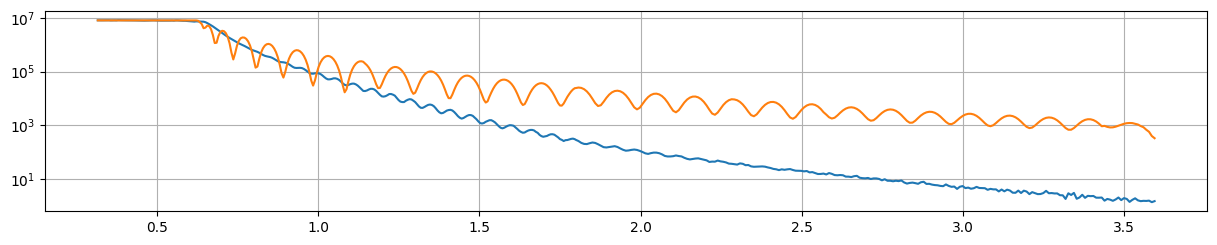

relative_loss:   0.3924770331862523 
 d:   tensor([8.4919e+02, 2.0019e+02, 1.2318e+01, 8.9167e+00, 1.0000e+02, 1.0000e-03])     grad_d:   tensor([2.0735e-02, 9.4733e-05, 2.8182e-01, 1.0932e+00, 0.0000e+00, 5.3761e-01]) 
 rho:   tensor([88.8279-7.0000j,  8.0049-2.7666j,  7.7947-0.4064j])     grad_rho:   tensor([ 0.3628-0.0002j,  0.6879+0.1404j, -0.0061+0.0075j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(2.1924e-08, dtype=torch.float64) 
 Ibkg:   tensor(3.1340, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0568, dtype=torch.float64) 
 learning_rate:   7.086739046911998 
 iteration:   130 



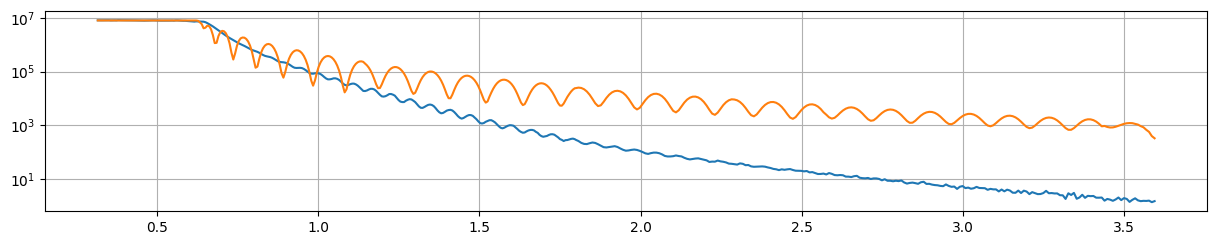

relative_loss:   0.4986435125617934 
 d:   tensor([857.3266, 222.3039,   8.3708,   5.4482, 100.0000,   0.0000])     grad_d:   tensor([ 3.8652e-03,  9.5173e-04,  4.8549e+00, -3.1742e+00,  0.0000e+00,
         4.2704e+00]) 
 rho:   tensor([88.8095-7.0890j,  8.1414-2.4910j,  7.1366-0.1000j])     grad_rho:   tensor([ 1.1047+0.1142j, -2.0699-2.0665j,  0.1044-0.0032j]) 
 I:   tensor(7992650.6583, dtype=torch.float64)     grad_I:   tensor(-3.5735e-08, dtype=torch.float64) 
 Ibkg:   tensor(3.2470, dtype=torch.float64)     grad_Ibkg:   tensor(0.0866, dtype=torch.float64) 
 learning_rate:   6.277733789878399 
 iteration:   259 



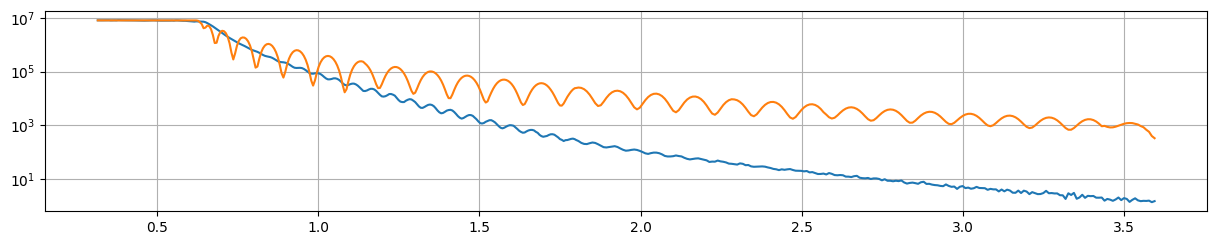

In [12]:
ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss, rel_losses2 = adamw(q, r, objective_function_weightless.objective_function, 
                                                                      ans_sigma1, ans_sigma2, 
                                                                      ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, 
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.008, max_iter = 260, k=3)

relative_loss:   1.0 
 d:   tensor([8.5524e+02, 2.1693e+02, 1.1499e+01, 6.2207e+00, 1.0000e+02, 1.0000e-03])     grad_d:   tensor([ 1.2706e-02, -3.2642e-04, -1.1381e+00,  7.3530e-01,  0.0000e+00,
        -8.5815e-01]) 
 rho:   tensor([88.7991-7.0000j,  8.1462-2.9218j,  7.1274-0.1450j])     grad_rho:   tensor([0.6495-0.0962j, 0.0810+0.8121j, 0.0186+0.0044j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(9.7985e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.1824, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0247, dtype=torch.float64) 
 learning_rate:   0.5 
 iteration:   1 



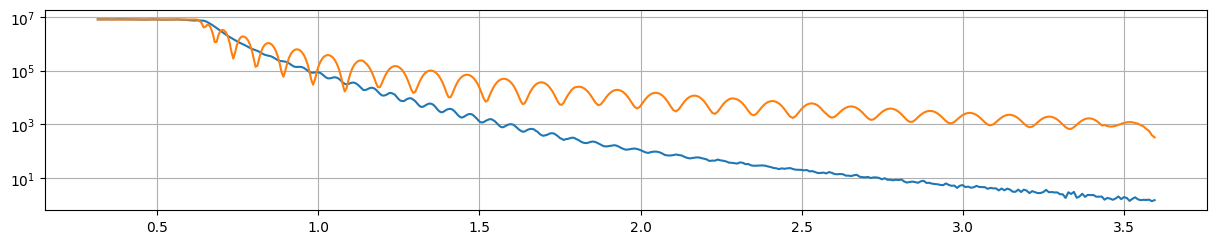

relative_loss:   0.46278073499915456 
 d:   tensor([8.5152e+02, 2.2278e+02, 1.4190e+01, 5.6984e+00, 1.0000e+02, 1.0000e-03])     grad_d:   tensor([ 2.6785e-05,  3.4048e-07, -4.4190e-03, -2.1322e-03,  0.0000e+00,
        -1.2277e-02]) 
 rho:   tensor([88.8271-7.1118j,  8.1628-2.0903j,  7.0853-0.1000j])     grad_rho:   tensor([-0.0828+0.0017j, -0.0321-0.0272j,  0.0238-0.0022j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(1.3270e-10, dtype=torch.float64) 
 Ibkg:   tensor(3.2657, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0003, dtype=torch.float64) 
 learning_rate:   0.46118407999999994 
 iteration:   89 



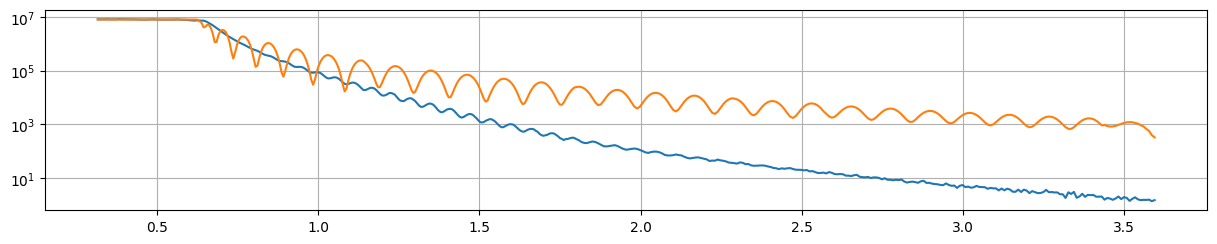

relative_loss:   0.4599886818182018 
 d:   tensor([851.0702, 222.6126,  14.9051,   6.1863, 100.0000,   0.0000])     grad_d:   tensor([-5.0977e-04, -1.3305e-07, -3.9281e-02,  4.2021e-02,  0.0000e+00,
        -3.5320e-02]) 
 rho:   tensor([88.8507-7.3566j,  8.1769-1.4617j,  7.0479-0.1000j])     grad_rho:   tensor([-0.0480-0.0006j,  0.0148+0.0143j,  0.0214-0.0024j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(4.8665e-10, dtype=torch.float64) 
 Ibkg:   tensor(3.2994, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0012, dtype=torch.float64) 
 learning_rate:   0.4253815112908927 
 iteration:   177 



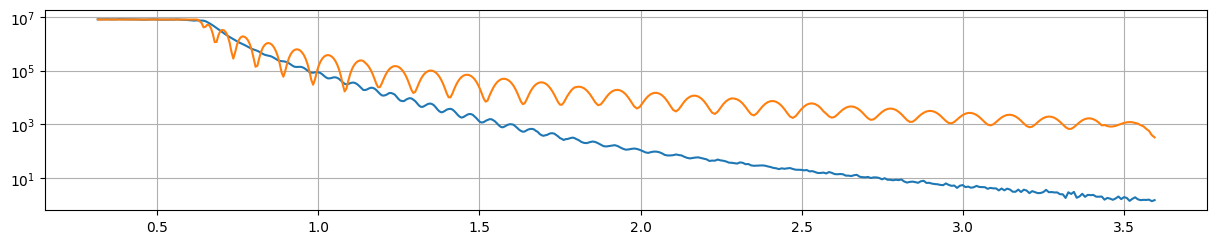

relative_loss:   0.4594433391254858 
 d:   tensor([8.5109e+02, 2.2262e+02, 1.4960e+01, 6.1706e+00, 1.0000e+02, 1.0000e-03])     grad_d:   tensor([-1.5409e-05, -2.0500e-08, -1.3542e-03,  1.3929e-03,  0.0000e+00,
        -2.2183e-03]) 
 rho:   tensor([88.8750-7.3692j,  8.1845-1.4573j,  7.0130-0.1000j])     grad_rho:   tensor([-0.0339-5.0273e-05j, -0.0072+7.5273e-04j,  0.0218-2.1794e-03j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(8.9044e-11, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0002, dtype=torch.float64) 
 learning_rate:   0.3845111946300519 
 iteration:   265 



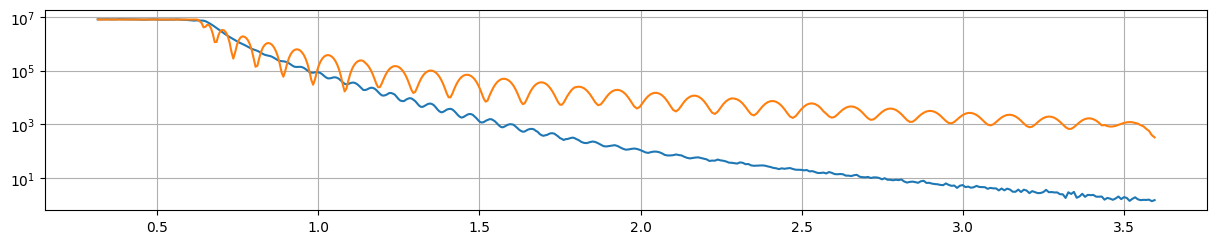

relative_loss:   0.4592392228676591 
 d:   tensor([851.0660, 222.6571,  14.8929,   6.2002, 100.0000,   0.0000])     grad_d:   tensor([ 3.6704e-04, -2.2275e-06,  3.2899e-02, -3.3177e-02,  0.0000e+00,
         2.7372e-02]) 
 rho:   tensor([88.9025-7.3671j,  8.1927-1.5022j,  6.9807-0.1000j])     grad_rho:   tensor([-0.0266+0.0011j, -0.0246-0.0149j,  0.0222-0.0020j]) 
 I:   tensor(7992650.6583, dtype=torch.float64)     grad_I:   tensor(-2.4157e-10, dtype=torch.float64) 
 Ibkg:   tensor(3.2997, dtype=torch.float64)     grad_Ibkg:   tensor(0.0006, dtype=torch.float64) 
 learning_rate:   0.35466088309032284 
 iteration:   353 



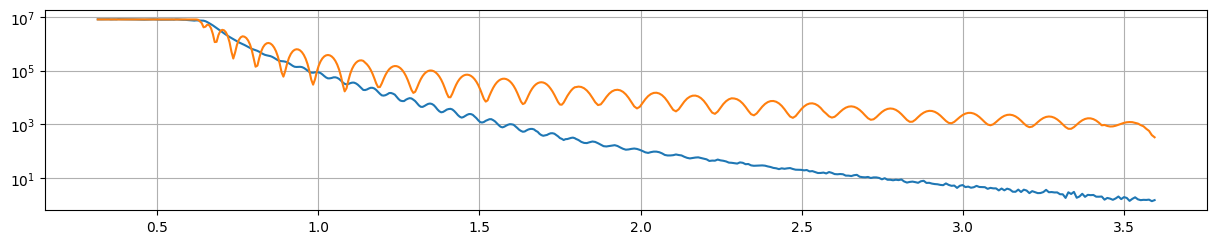

relative_loss:   0.45880666945550574 
 d:   tensor([851.1079, 222.6286,  14.9015,   6.1659, 100.0000,   0.0000])     grad_d:   tensor([ 9.0565e-05, -3.4601e-07,  7.7966e-03, -7.9194e-03,  0.0000e+00,
         5.5887e-03]) 
 rho:   tensor([88.9297-7.3613j,  8.2008-1.5414j,  6.9510-0.1000j])     grad_rho:   tensor([-0.0283+0.0003j, -0.0121-0.0031j,  0.0217-0.0021j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(6.1827e-13, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-1.4885e-06, dtype=torch.float64) 
 learning_rate:   0.3205853480367962 
 iteration:   441 



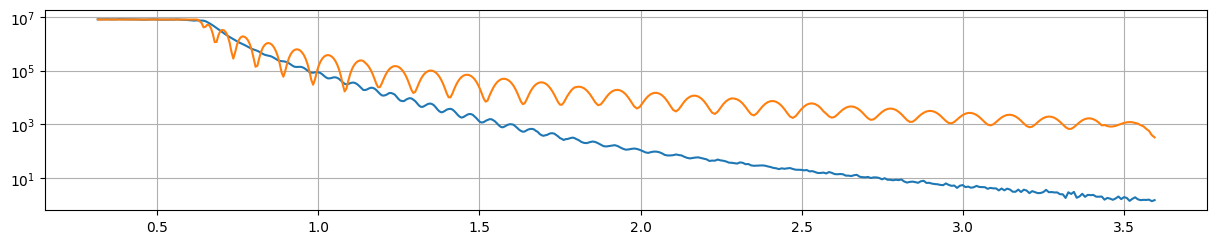

relative_loss:   0.4585227185051503 
 d:   tensor([8.5113e+02, 2.2263e+02, 1.4881e+01, 6.1494e+00, 1.0000e+02, 1.0000e-03])     grad_d:   tensor([ 3.8560e-06, -9.4453e-08,  3.9143e-04, -3.7526e-04,  0.0000e+00,
        -8.4808e-04]) 
 rho:   tensor([88.9548-7.3557j,  8.2089-1.5842j,  6.9238-0.1000j])     grad_rho:   tensor([-0.0280+1.3330e-05j, -0.0084+1.2530e-04j,  0.0215-2.1705e-03j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(7.4236e-11, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0002, dtype=torch.float64) 
 learning_rate:   0.2956977175916593 
 iteration:   529 



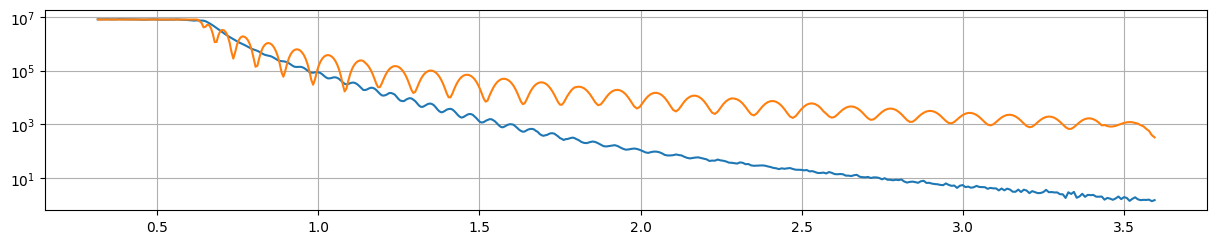

relative_loss:   0.4582871012205949 
 d:   tensor([851.1347, 222.6350,  14.8444,   6.1437, 100.0000,   0.0000])     grad_d:   tensor([ 1.1662e-04, -5.0225e-07,  9.9334e-03, -1.0355e-02,  0.0000e+00,
         7.1910e-03]) 
 rho:   tensor([88.9778-7.3507j,  8.2172-1.6250j,  6.8990-0.1000j])     grad_rho:   tensor([-0.0246+0.0004j, -0.0140-0.0040j,  0.0216-0.0021j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(-2.1547e-11, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(5.1875e-05, dtype=torch.float64) 
 learning_rate:   0.27274215969121846 
 iteration:   617 



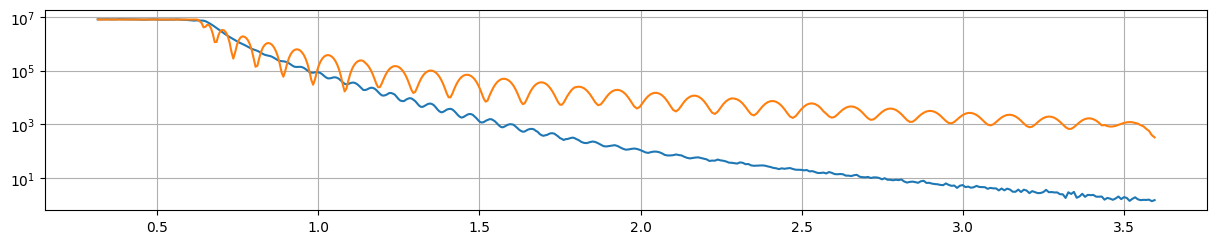

relative_loss:   0.4580529570789326 
 d:   tensor([8.5115e+02, 2.2263e+02, 1.4831e+01, 6.1288e+00, 1.0000e+02, 1.0000e-03])     grad_d:   tensor([-1.6134e-05,  2.0745e-07, -1.3106e-03,  1.3969e-03,  0.0000e+00,
        -2.3797e-03]) 
 rho:   tensor([88.9991-7.3475j,  8.2253-1.6584j,  6.8762-0.1000j])     grad_rho:   tensor([-0.0253-4.8013e-05j, -0.0075+8.5840e-04j,  0.0214-2.1768e-03j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(9.2493e-11, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0002, dtype=torch.float64) 
 learning_rate:   0.246537310309039 
 iteration:   705 



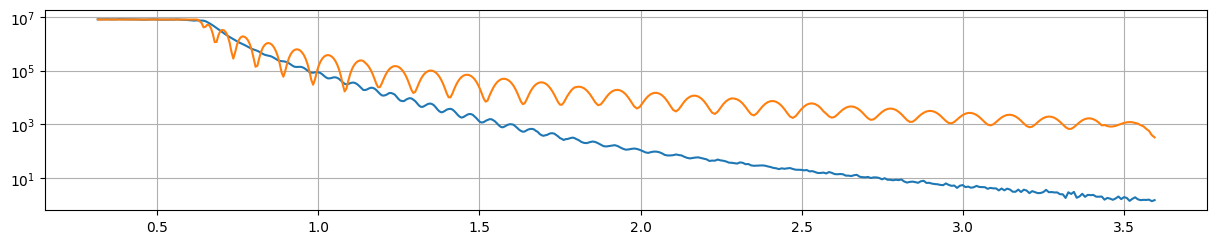

relative_loss:   0.4578612594376023 
 d:   tensor([8.5117e+02, 2.2263e+02, 1.4808e+01, 6.1106e+00, 1.0000e+02, 1.0000e-03])     grad_d:   tensor([-8.3813e-05,  4.9605e-07, -7.3984e-03,  7.3391e-03,  0.0000e+00,
        -7.6175e-03]) 
 rho:   tensor([89.0185-7.3418j,  8.2331-1.6953j,  6.8554-0.1000j])     grad_rho:   tensor([-0.0250-0.0002j, -0.0049+0.0035j,  0.0213-0.0022j]) 
 I:   tensor(7944838.1917, dtype=torch.float64)     grad_I:   tensor(1.5035e-10, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0004, dtype=torch.float64) 
 learning_rate:   0.22739816528109733 
 iteration:   793 



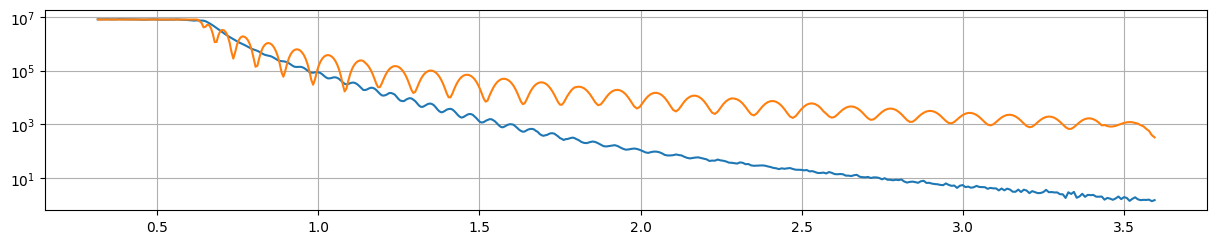

In [13]:
objective_function_weightless_sigma = varsigma(ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss_function.compare_weightless, all_bounds)
ans_sigma1, ans_sigma2 = de(
    func=objective_function_weightless_sigma.objective_function,
    bounds=bounds,
).x

ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss, rel_losses3 = adamw(q, r, objective_function_weightless.objective_function, 
                                                                      ans_sigma1, ans_sigma2, 
                                                                      ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, 
                                                                      d_bounds, r_rho_bounds, i_rho_bounds, I_bounds, Ibkg_bounds,
                                                                      lr= 0.0005, max_iter = 800, k=10)

In [14]:
rel_losses2 = list(map(lambda x: x * rel_losses1[-1],  rel_losses2))
rel_losses3 = list(map(lambda x: x * rel_losses2[-1],  rel_losses3))
rel_losses = rel_losses1 + rel_losses2 + rel_losses3

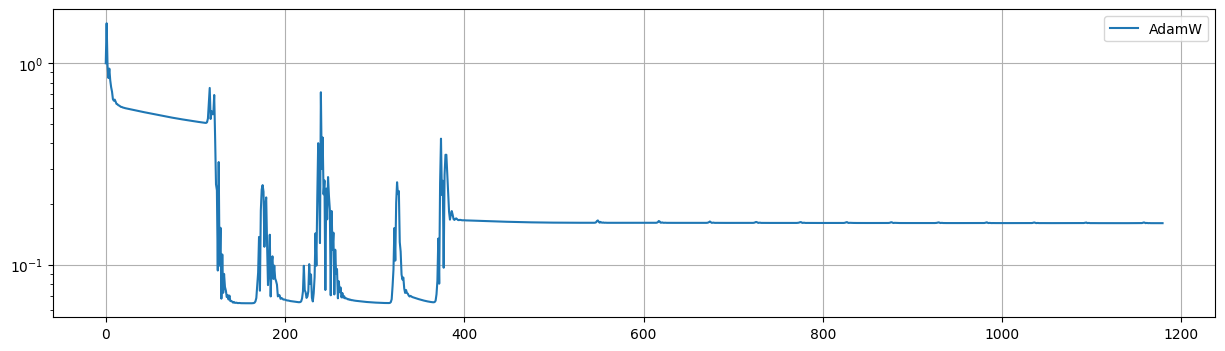

In [15]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses)), rel_losses, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [16]:
ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss

(tensor([8.5116e+02, 2.2264e+02, 1.4800e+01, 6.1188e+00, 1.0000e+02, 1.0000e-03]),
 tensor([89.0200,  8.2336,  6.8538]),
 tensor([-7.3429, -1.6959, -0.1000]),
 tensor(7944838.1917, dtype=torch.float64),
 tensor(3.3000, dtype=torch.float64),
 2.298736151524108)

In [17]:
ans_sigma1, ans_sigma2

(np.float64(0.019306032927362753), np.float64(0.019991009130897283))